New photo-z's using DESI redshifts for training

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

sys.path.append(os.path.expanduser('~/git/desi-photoz/'))
import pz_modules

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

# Main LRGs

In [12]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/main/main-lrg-daily-thru20210615-add_pz_new.fits'))
print(len(cat))

291793


In [13]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['COADD_EFFTIME_GFA']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Remove not-done fibers
# mask = cat['ZDONE']==1
# cat = cat[mask]
# print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

FIBERSTATUS    3475 288318 0.011909127360834564
No data    0 288318 0.0
Min depth    4533 283785 0.015722223378353068


In [16]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']) - 2.165 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [17]:
mask_quality0 = cat['ZWARN']==0
mask_quality0 &= cat['DELTACHI2']>15
mask_quality0 &= cat['Z']<1.4
print(np.sum(~mask_quality0)/len(mask_quality0))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

# Custom cut with DELTACHI2>15
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<15)
mask_quality1 = cat['ZWARN']==0
mask_quality1 &= cat['Z']<1.4
mask_quality1 &= (~mask_remove)
print(np.sum(~mask_quality1)/len(mask_quality1))

0.025473509875433866
0.023366280811177476
0.02730588297478725


In [18]:
cat = cat[mask_quality]
print(len(cat))

277154


In [19]:
# WISE and MEDIUM masks
maskbits = [8, 9, 11]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
cat = cat[mask_clean]

MASKBITS 255973 21181 0.9235767840262092


In [20]:
# Remove QSO targets
mask_qso = cat['DESI_TARGET'] & 2**2 > 0
print(np.sum(mask_qso)/len(cat))

cat = cat[~mask_qso]
print(len(cat))

0.013864743547170991
252424


In [21]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

76533 175891


Normalized MAD: 0.025619
0.10 outliers: 2.488274%


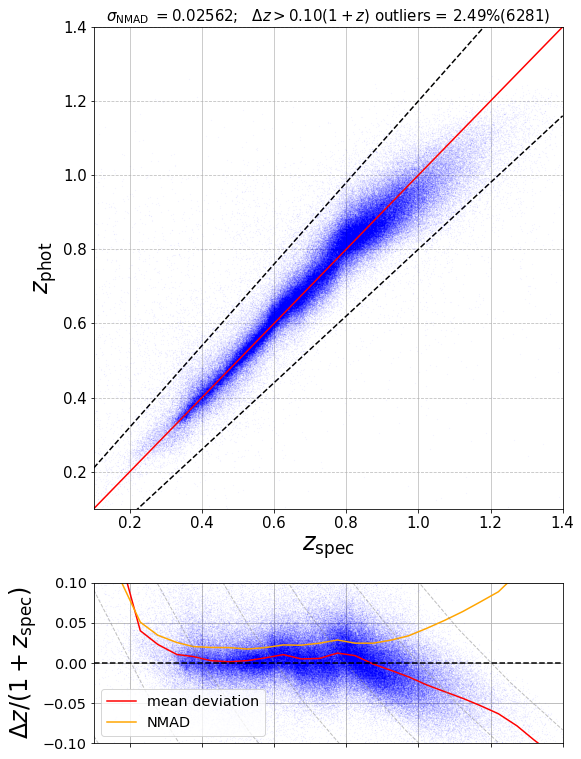

In [25]:
mask = np.full(len(cat), True)
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=0.1, zmin=0.1, zmax=1.4, verbose=False, alpha=0.3)

Normalized MAD: 0.025167
0.10 outliers: 2.462889%


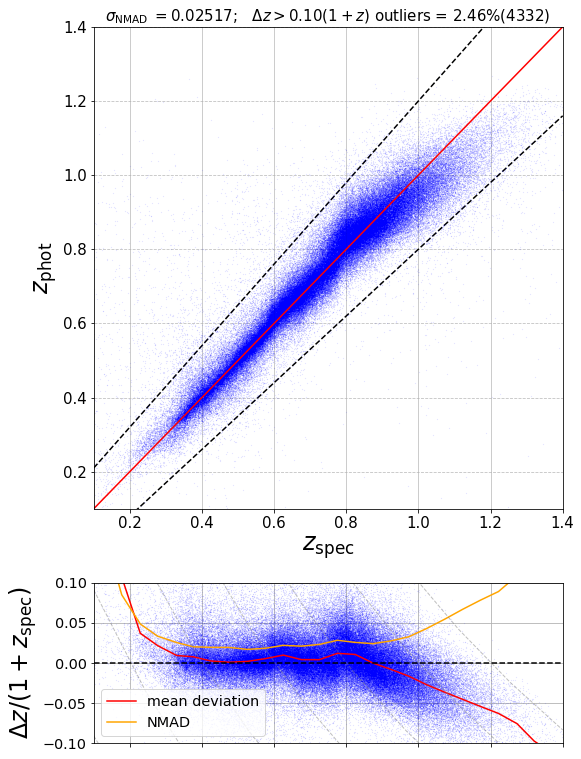

In [30]:
mask = mask_south.copy()
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=0.4, zmin=0.1, zmax=1.4, verbose=False)

Normalized MAD: 0.026636
0.10 outliers: 2.546614%


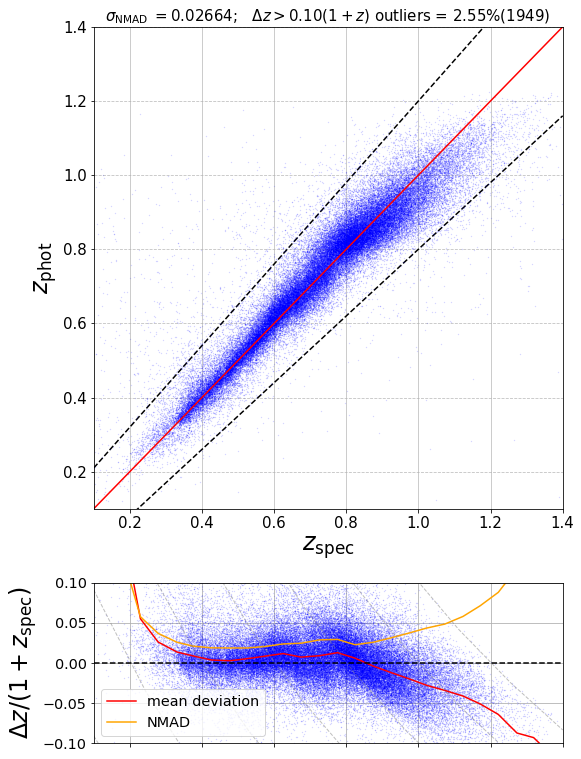

In [31]:
mask = mask_north.copy()
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=0.7, zmin=0.1, zmax=1.4, verbose=False)